# Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import skew, ttest_ind
from functions import plot
from statsmodels.stats.multitest import multipletests
import dash_bio
from adjustText import adjust_text
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Variables

In [3]:
log_trans = True

# Format data

In [4]:
df_org = pd.read_excel("../data/unformated/Daten_Label_24hWt.xlsx", sheet_name="formatted")
rows_unl = [i for i in range(len(df_org)) if i % 2 == 0]
rows_l = [i for i in range(len(df_org)) if i % 2 != 0]
df = df_org.drop(rows_l, axis=0)
df_l = df_org.drop(rows_unl, axis=0)

In [5]:
# add labeled values as new columns
cols = df_org.columns[1:]
for col in cols:
    df[f"{col}_l"] = df_l[col].values

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing
## Replace zero values
- replace zero values with half minimum value, because log(0) not possible

In [6]:
half_min = np.min([val for val in df.filter(regex=r"^(?!.*compound).*$").values.flatten() if val != 0]) / 2
print("Half minimum:", half_min)

for col in df.columns:
    if col == "compound":
        continue

    df[col] = df[col].replace(0, half_min)

df

Half minimum: 4.0672700112186134e-05


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000041,0.000041,1.440343,1.202063,0.000041,0.042314,0.000041,0.685638,1.190872,0.000041
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000041,0.000041,0.000041,0.000041,0.020399,0.023651,0.000041,0.000041,0.000041
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041


## Relative values

In [7]:
cols = df.columns[1:]

for col in cols:
    exp = col.split("_")[0]
    exp_cols = [col for col in cols if "rel" not in col and exp in col]
    sum_exp = df[exp_cols].to_numpy().sum()
    abs_values = df[col].values
    rel_values = [val/sum_exp for val in abs_values]

    df[f"{col}_rel"] = rel_values

    # print("Experiment:", exp)
    # print("Experiment columns:", exp_cols)
    # print("Sum experiment:", sum_exp)
    # print("Column:", col)
    # print("Absolute values:", abs_values)
    # print("Relative values:", rel_values)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.162409e-03,1.266035e-03,2.456538e-04,2.383859e-04,1.416420e-04,1.739084e-04,1.144567e-03,1.811818e-03,1.705142e-03,1.174039e-03
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,3.642664e-08,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.126304e-03,3.968674e-03,3.485184e-04,3.873868e-04,2.408937e-04,2.866959e-04,3.608474e-03,3.784976e-03,2.986134e-03,2.778177e-03
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,2.798325e-04,3.221959e-04,5.361206e-04,4.871307e-04,3.050952e-04,3.914849e-04,8.575436e-04,1.079570e-03,1.259768e-03,7.726764e-04
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,4.985460e-04,4.632801e-04,5.215333e-04,5.047056e-04,3.478836e-04,3.345650e-04,1.068967e-03,1.046212e-03,9.246646e-04,8.377694e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,3.642664e-08,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,3.642664e-08,3.642664e-08,1.643665e-04,1.371749e-04,4.641415e-09,4.828770e-06,4.641415e-09,7.824247e-05,1.358979e-04,4.641415e-09
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,2.908229e-06,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,2.327842e-06,2.698922e-06,4.641415e-09,4.641415e-09,4.641415e-09
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,3.642664e-08,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09


In [8]:
df.filter(regex="exp2").filter(regex="rel").to_numpy().sum()

np.float64(0.9999999999999999)

In [9]:
df.filter(regex="exp4").filter(regex="rel").to_numpy().sum()

np.float64(1.0)

## log Transformation

In [10]:
if log_trans == True:
    rel_cols = [c for c in df.columns if "rel" in c]
    print(rel_cols)

    for col in rel_cols:
        df[col] = np.log(df[col].values)

df

['exp2_22deg_1_rel', 'exp2_22deg_2_rel', 'exp2_22deg_3_rel', 'exp2_22deg_4_rel', 'exp2_37deg_1_rel', 'exp2_37deg_2_rel', 'exp2_37deg_3_rel', 'exp2_37deg_4_rel', 'exp4_22deg_1_rel', 'exp4_22deg_2_rel', 'exp4_22deg_3_rel', 'exp4_22deg_4_rel', 'exp4_37deg_1_rel', 'exp4_37deg_2_rel', 'exp4_37deg_3_rel', 'exp4_37deg_4_rel', 'exp2_22deg_1_l_rel', 'exp2_22deg_2_l_rel', 'exp2_22deg_3_l_rel', 'exp2_22deg_4_l_rel', 'exp2_37deg_1_l_rel', 'exp2_37deg_2_l_rel', 'exp2_37deg_3_l_rel', 'exp2_37deg_4_l_rel', 'exp4_22deg_1_l_rel', 'exp4_22deg_2_l_rel', 'exp4_22deg_3_l_rel', 'exp4_22deg_4_l_rel', 'exp4_37deg_1_l_rel', 'exp4_37deg_2_l_rel', 'exp4_37deg_3_l_rel', 'exp4_37deg_4_l_rel']


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.757261,-6.671866,-8.311587,-8.341620,-8.862208,-8.656982,-6.772728,-6.313424,-6.374107,-6.747305
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-17.127966,-17.127966,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.490373,-5.529323,-7.961819,-7.856087,-8.331155,-8.157089,-5.624470,-5.576716,-5.813776,-5.885960
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-8.181319,-8.040351,-7.531151,-7.626978,-8.094887,-7.845564,-7.061439,-6.831192,-6.676828,-7.165650
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-7.603815,-7.677179,-7.558738,-7.591535,-7.963643,-8.002680,-6.841062,-6.862579,-6.986079,-7.084768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-17.127966,-17.127966,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-17.127966,-17.127966,-8.713412,-8.894254,-19.188247,-12.240919,-19.188247,-9.455698,-8.903607,-19.188247
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-12.747966,-17.127966,-19.188247,-19.188247,-19.188247,-12.970569,-12.822658,-19.188247,-19.188247,-19.188247
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-17.127966,-17.127966,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247


## Add labeled and unlabeled

In [11]:
for col in [c for c in df.columns[1:] if "rel" in c and "_l_" not in c]:
    col_l = "_".join(col.split("_")[:-1]) + "_l_rel"
    df[f"{"sum_" + "_".join(col.split("_")[:-1])}"] = df[[col, col_l]].sum(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-14.373977,-14.078207,-15.793497,-15.934775,-16.575837,-16.305217,-14.505424,-13.848155,-14.061455,-14.537177
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-27.421669,-28.107106,-29.877073,-30.821045,-30.772979,-28.971683,-30.240653,-27.005095,-30.201498,-29.485047
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-11.421346,-11.444453,-14.878334,-14.836248,-15.466414,-15.307309,-12.203322,-12.057648,-12.459394,-12.705333
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-16.165790,-15.971605,-14.030134,-14.243824,-14.890816,-14.682721,-14.268064,-14.230827,-14.143871,-14.620973
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-15.209050,-15.329086,-14.273459,-14.473296,-14.848663,-15.104839,-13.914482,-13.737037,-13.820050,-14.255740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-34.255931,-34.255931,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-22.385644,-22.194671,-13.386516,-13.657191,-23.942127,-16.855151,-24.117286,-14.304301,-13.602439,-24.169032
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-22.097808,-26.250289,-27.111194,-27.239533,-27.038888,-20.749499,-21.045271,-27.313633,-26.952180,-27.380740
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-34.255931,-34.255931,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493,-38.376493


## Statistics

### Mean and Std

In [12]:
# means per experiment and condition
groups = ["sum_exp2_22deg", "sum_exp2_37deg", "sum_exp4_22deg", "sum_exp4_37deg"]

for g in groups:
    df[f"mean_{g}"] = df.filter(regex=g).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=g).std(axis=1)

In [13]:
# mean per condition
for f, g in zip([r"^sum_exp\d_22deg", r"^sum_exp\d_22deg"], ["all_22deg", "all_37deg"]):
    df[f"mean_{g}"] = df.filter(regex=f).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=f).std(axis=1, ddof=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,mean_sum_exp2_37deg,sd_sum_exp2_37deg,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg,mean_all_22deg,sd_all_22deg,mean_all_37deg,sd_all_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-14.166398,0.141766,-16.152332,0.307743,-14.238053,0.293330,-15.755435,0.500713,-15.755435,0.500713
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-27.663679,0.301133,-30.110695,0.757487,-29.233073,1.321026,-31.345014,2.624479,-31.345014,2.624479
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-11.555287,0.122985,-15.122076,0.271103,-12.356424,0.247511,-14.817182,0.495843,-14.817182,0.495843
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-16.172863,0.139875,-14.461874,0.341581,-14.315934,0.181789,-14.189746,0.409718,-14.189746,0.409718
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-15.445791,0.182969,-14.675064,0.322816,-13.931827,0.197268,-14.777268,0.446618,-14.777268,0.446618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-34.255931,0.000000,-38.376493,0.000000,-38.376493,0.000000,-36.316212,2.202533,-36.316212,2.202533
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-22.310727,0.071068,-16.960246,4.255568,-19.048265,5.100967,-19.655064,4.318631,-19.655064,4.318631
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-24.168796,2.064754,-25.534778,2.763717,-25.672956,2.676763,-25.616201,2.264096,-25.616201,2.264096
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-34.255931,0.000000,-38.376493,0.000000,-38.376493,0.000000,-36.316212,2.202533,-36.316212,2.202533


### T-test

In [14]:
## ttest between 22deg and 37deg per experiment
for control, heat, label in [[r"^sum_exp2_22deg_\d+", r"^sum_exp2_37deg_\d+", "exp2"], [r"^sum_exp4_22deg_\d+", r"^sum_exp4_37deg_\d+", "exp4"]]:
    df[f"t_stat_{label}"], df[f"p_val_{label}"] = ttest_ind(df.filter(regex=control), df.filter(regex=heat), axis=1)

    # mask NaN values
    pvals = df[f"p_val_{label}"].values
    mask = ~np.isnan(pvals)
    adj_pvals = np.full_like(pvals, np.nan)
    adj_pvals[mask] = multipletests(pvals[mask], method="fdr_bh")[1] # -> Benjamin-Hochberg correction

    df[f"p_val_{label}_adj"] = adj_pvals
df

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,mean_all_22deg,sd_all_22deg,mean_all_37deg,sd_all_37deg,t_stat_exp2,p_val_exp2,p_val_exp2_adj,t_stat_exp4,p_val_exp4,p_val_exp4_adj
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-15.755435,0.500713,-15.755435,0.500713,-9.319841,0.000086,0.000540,-7.798818,0.000234,0.001424
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-31.345014,2.624479,-31.345014,2.624479,-2.916286,0.026760,0.064743,-0.998222,0.356712,0.440316
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-14.817182,0.495843,-14.817182,0.495843,-11.876776,0.000022,0.000180,-13.049069,0.000012,0.000110
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-14.189746,0.409718,-14.189746,0.409718,17.727746,0.000002,0.000078,-0.653263,0.537800,0.601349
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-14.777268,0.446618,-14.777268,0.446618,1.933213,0.101392,0.168986,-3.402759,0.014447,0.026953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-36.316212,2.202533,-36.316212,2.202533,NaN,NaN,NaN,NaN,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-19.655064,4.318631,-19.655064,4.318631,-0.691657,0.515011,0.559794,0.544414,0.605782,0.664678
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-25.616201,2.264096,-25.616201,2.264096,-1.120734,0.305244,0.401637,0.062204,0.952420,0.952420
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-36.316212,2.202533,-36.316212,2.202533,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
## ttest between exp2 and exp4 per condition
for exp2, exp4, label in [[r"^sum_exp2_22deg_\d+", r"^sum_exp4_22deg_\d+", "22deg"], [r"^sum_exp2_37deg_\d+", r"^sum_exp4_37deg_\d+", "37deg"]]:
    df[f"t_stat_{label}"], df[f"p_val_{label}"] = ttest_ind(df.filter(regex=exp2), df.filter(regex=exp4), axis=1)
    df[f"p_val_{label}_adj"] = multipletests(df[f"p_val_{label}"].values, method="fdr_bh")[1] # -> Benjamin-Hochberg correction

    # set inf values to NaN
    mask_inf = np.isinf(df[f"t_stat_{label}"]) | np.isinf(df[f"p_val_{label}"])
    df.loc[mask_inf, f"t_stat_{label}"] = np.nan
    df.loc[mask_inf, f"p_val_{label}"] = np.nan
    df.loc[mask_inf, f"p_val_{label}_adj"] = np.nan
    
df

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
C:\Users\janni\AppData\Local\Temp\ipykernel_11740\2480987924.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"t_stat_{label}"], df[f"p_val_{label}"] = ttest_ind(df.filter(regex=exp2), df.filter(regex=exp4), axis=1)
C:\Users\janni\AppData\Local\Temp\ipykernel_11740\2480987924.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_exp2_adj,t_stat_exp4,p_val_exp4,p_val_exp4_adj,t_stat_22deg,p_val_22deg,p_val_22deg_adj,t_stat_37deg,p_val_37deg,p_val_37deg_adj
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000540,-7.798818,0.000234,0.001424,3.909251,0.007899,0.012695,0.380948,0.716365,0.732646
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.064743,-0.998222,0.356712,0.440316,-1.424737,0.204107,0.232527,2.006231,0.091632,0.105499
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.000180,-13.049069,0.000012,0.000110,2.136714,0.076497,0.096968,5.020627,0.002403,0.003931
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000078,-0.653263,0.537800,0.601349,2.469945,0.048461,0.065097,-14.022084,0.000008,0.000024
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.168986,-3.402759,0.014447,0.026953,-0.618018,0.559276,0.606444,-9.746088,0.000067,0.000163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.559794,0.544414,0.605782,0.664678,-2.193349,0.070748,0.090961,-1.107673,0.310421,0.328681
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.401637,0.062204,0.952420,0.952420,-0.094241,0.927986,0.927986,0.770663,0.470155,0.486367
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


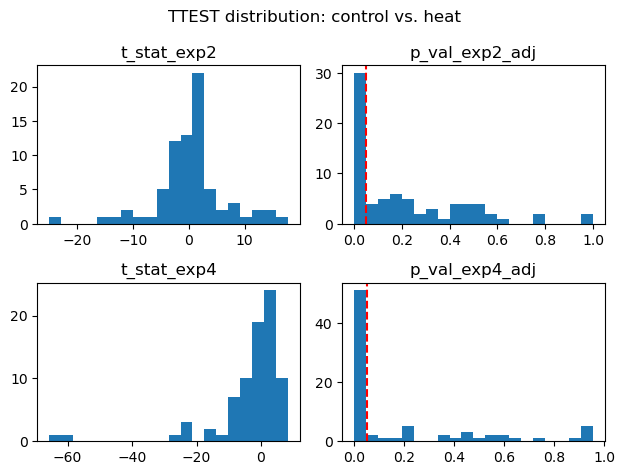

In [16]:
fig, axs = plot(2, 2, "TTEST distribution: control vs. heat", df, [["t_stat_exp2", "p_val_exp2_adj"], ["t_stat_exp4", "p_val_exp4_adj"]], 20)
axs[0, 1].axvline(0.05, linestyle="--", color="red")
axs[1, 1].axvline(0.05, linestyle="--", color="red")

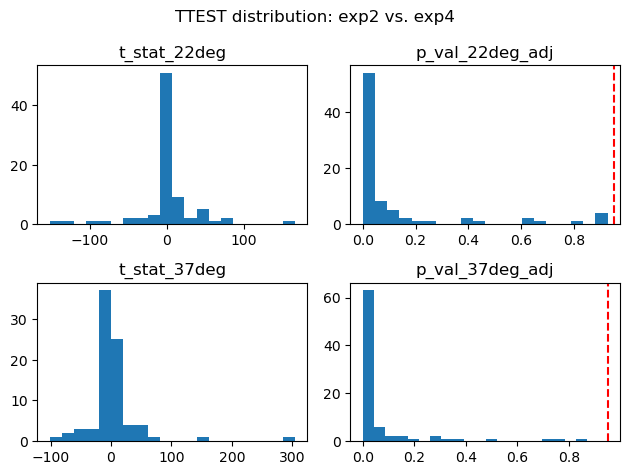

In [17]:
fig, axs = plot(2, 2, "TTEST distribution: exp2 vs. exp4", df, [["t_stat_22deg", "p_val_22deg_adj"], ["t_stat_37deg", "p_val_37deg_adj"]], 20)
axs[0, 1].axvline(0.95, linestyle="--", color="red")
axs[1, 1].axvline(0.95, linestyle="--", color="red")

### Fold change

In [14]:
## fold change between 22deg and 37deg
df["log2_fc"] = df["mean_37deg"] - df["mean_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df["log2_fc_l"] = df["mean_37deg_l"] - df["mean_22deg_l"]
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,mean_37deg_l,sd_37deg_l,t_stat,p_val,p_val_adj,t_stat_l,p_val_l,p_val_l_adj,log2_fc,log2_fc_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.642695,0.189664,-1.855890,0.084641,0.217647,-6.689172,1.028446e-05,0.217647,0.149932,1.403277
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-18.158106,1.101266,-2.352883,0.033777,0.121598,0.000000,1.000000e+00,0.121598,2.896638,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.691142,0.152419,-5.339919,0.000104,0.001043,-11.673109,1.332222e-08,0.001043,0.866858,1.994469
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-7.561858,0.691253,8.102152,0.000001,0.000035,0.112026,9.123928e-01,0.000035,-1.024581,-0.030071
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-7.378252,0.488697,0.999204,0.334654,0.621088,-1.301147,2.142155e-01,0.621088,-0.172103,0.260561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-18.158106,1.101266,0.000000,1.000000,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-15.655958,4.099805,0.505461,0.621099,0.961844,0.467826,6.471083e-01,0.961844,-0.062061,-0.962371
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-16.287900,2.990075,0.084159,0.934122,1.000000,-0.538965,5.983779e-01,1.000000,-0.029158,0.724482
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-18.158106,1.101266,0.000000,1.000000,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000


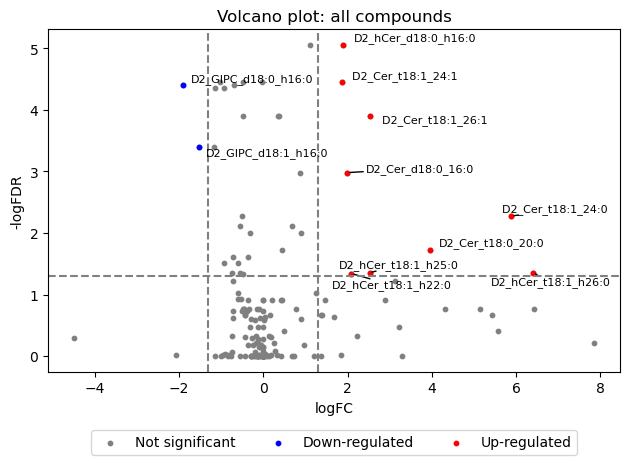

In [15]:
# combine labeled and unlabeled compounds in one df
fc_df = pd.concat([df["log2_fc"], df["log2_fc_l"]])
p_df = pd.concat([df["p_val_adj"], df["p_val_l_adj"]])
compounds_all = list(df["compound"].values) + list("D2_" + df["compound"].values)
df_volcano = pd.concat([ fc_df, p_df], axis=1)
df_volcano.columns = ["log2_fc", "p_val_adj"]
df_volcano["compounds"] = compounds_all

size = 10
plt.scatter(x=df_volcano["log2_fc"], y=df_volcano["p_val_adj"].apply(lambda x:-np.log10(x)), s=size, label="Not significant", color="grey")

# highlight down- or up- regulated metabolites
signif = 0.05
level = -np.log10(signif)
down = df_volcano[(df_volcano["log2_fc"] <= level * -1) & (df_volcano["p_val_adj"] <= signif)]
up = df_volcano[(df_volcano["log2_fc"] >= level) & (df_volcano["p_val_adj"] <= signif)]
plt.scatter(x=down["log2_fc"], y=down["p_val_adj"].apply(lambda x:-np.log10(x)), s=size, label="Down-regulated", color="blue")
plt.scatter(x=up["log2_fc"], y=up["p_val_adj"].apply(lambda x:-np.log10(x)), s=size, label="Up-regulated", color="red")

# add texts
texts=[]
for i,r in up.iterrows():
    texts.append(plt.text(x=r['log2_fc'],y=-np.log10(r['p_val_adj']),s=r["compounds"], fontsize=8))

for i,r in down.iterrows():
    texts.append(plt.text(x=r['log2_fc'],y=-np.log10(r['p_val_adj']),s=r["compounds"], fontsize=8))

adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=1))

plt.title("Volcano plot: all compounds")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(level*-1, color="grey", linestyle="--")
plt.axvline(level, color="grey", linestyle="--")
plt.axhline(level, color="grey", linestyle="--")
plt.legend(bbox_to_anchor=(0.5, -0.15), ncol=3, loc="upper center")
plt.tight_layout()

### Skewness

In [16]:
df["skew_22deg_abs"] = [skew(df.filter(regex=r".*_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_37deg_abs"] = [skew(df.filter(regex=r".*_37deg_\d+$").values[i]) for i in range(len(df))]
df["skew_22deg_rel"] = [skew(df.filter(regex=r".*_22deg_\d+_rel$").values[i]) for i in range(len(df))]
df["skew_37deg_rel"] = [skew(df.filter(regex=r".*_37deg_\d+_rel$").values[i]) for i in range(len(df))]
df

C:\Users\janni\AppData\Local\Temp\ipykernel_23432\2819833365.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_22deg_abs"] = [skew(df.filter(regex=r".*_22deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_23432\2819833365.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_37deg_abs"] = [skew(df.filter(regex=r".*_37deg_\d+$").values[i]) for i in range(len(df))]


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj,t_stat_l,p_val_l,p_val_l_adj,log2_fc,log2_fc_l,skew_22deg_abs,skew_37deg_abs,skew_22deg_rel,skew_37deg_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.217647,-6.689172,1.028446e-05,0.217647,0.149932,1.403277,0.054856,0.080237,-0.243084,0.135326
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.121598,0.000000,1.000000e+00,0.121598,2.896638,0.000000,1.661996,2.241589,-0.416579,1.801308
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.001043,-11.673109,1.332222e-08,0.001043,0.866858,1.994469,0.068238,0.142589,-0.185771,-0.155612
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000035,0.112026,9.123928e-01,0.000035,-1.024581,-0.030071,0.144948,0.086108,0.123299,0.161683
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.621088,-1.301147,2.142155e-01,0.621088,-0.172103,0.260561,0.117633,0.120059,-0.267947,0.224132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.961844,0.467826,6.471083e-01,0.961844,-0.062061,-0.962371,0.026585,0.087619,-0.022294,0.321832
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,1.000000,-0.538965,5.983779e-01,1.000000,-0.029158,0.724482,0.059257,0.264747,-0.027168,0.118000
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: title={'center': 'skew_22deg_abs'}>,
         <Axes: title={'center': 'skew_37deg_abs'}>],
        [<Axes: title={'center': 'skew_22deg_rel'}>,
         <Axes: title={'center': 'skew_37deg_rel'}>]], dtype=object))

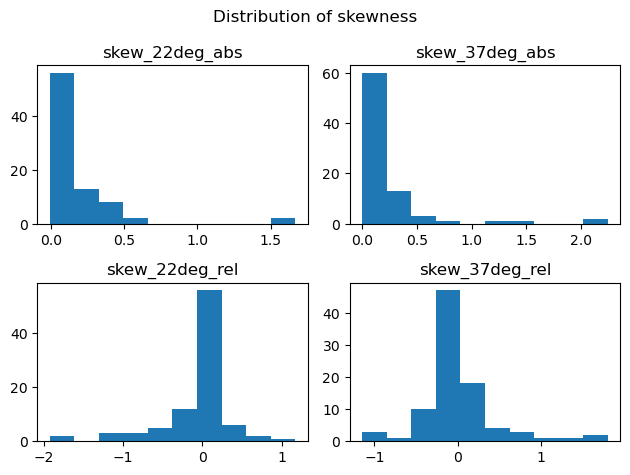

In [17]:
plot(2, 2, "Distribution of skewness", df, [["skew_22deg_abs", "skew_37deg_abs"], ["skew_22deg_rel", "skew_37deg_rel"]])

## Degree of labeling

In [18]:
df["sum_22deg"] = df[["mean_22deg", "mean_22deg_l"]].sum(axis=1)
df["sum_37deg"] = df[["mean_37deg", "mean_37deg_l"]].sum(axis=1)
df["dol_22deg"] = df["mean_22deg_l"] /  df["sum_22deg"]
df["dol_37deg"] = df["mean_37deg_l"] /  df["sum_37deg"]
df.to_csv("../data/formated/wt_24h.csv", index=False)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,log2_fc,log2_fc_l,skew_22deg_abs,skew_37deg_abs,skew_22deg_rel,skew_37deg_rel,sum_22deg,sum_37deg,dol_22deg,dol_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.149932,1.403277,0.054856,0.080237,-0.243084,0.135326,-15.755435,-14.202225,0.510679,0.467722
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,2.896638,0.000000,1.661996,2.241589,-0.416579,1.801308,-31.345014,-28.448376,0.579298,0.638283
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.866858,1.994469,0.068238,0.142589,-0.185771,-0.155612,-14.817182,-11.955855,0.518696,0.476013
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-1.024581,-0.030071,0.144948,0.086108,0.123299,0.161683,-14.189746,-15.244398,0.530791,0.496042
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-0.172103,0.260561,0.117633,0.120059,-0.267947,0.224132,-14.777268,-14.688809,0.516930,0.502304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000000,0.000000,NaN,NaN,0.000000,0.000000,-36.316212,-36.316212,0.500000,0.500000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-0.062061,-0.962371,0.026585,0.087619,-0.022294,0.321832,-19.655064,-20.679496,0.747573,0.757076
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-0.029158,0.724482,0.059257,0.264747,-0.027168,0.118000,-25.616201,-24.920876,0.664126,0.653585
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000000,0.000000,NaN,NaN,0.000000,0.000000,-36.316212,-36.316212,0.500000,0.500000


Text(0.5, 0.98, 'Distribution of labeling degree')

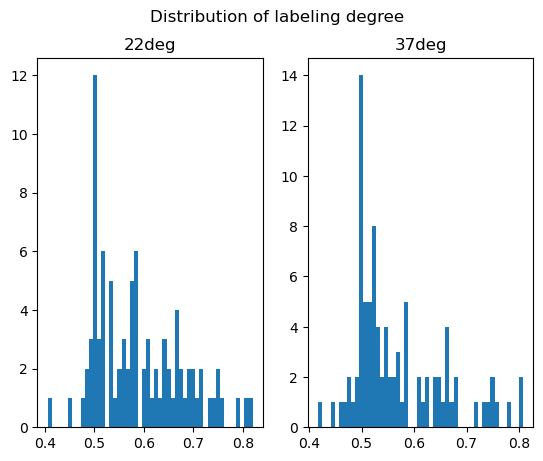

In [19]:
fig, axs = plt.subplots(1, 2)

for i, title in zip([0, 1], ["dol_22deg", "dol_37deg"]):
    axs[i].hist(df[title].values, bins=50)
    axs[i].set_title(f"{title.split("_")[1]}")

plt.suptitle("Distribution of labeling degree")

# Principle component analysis

## Centering and scaling
- x scaled = (x - mean(x)) / std(x)

In [20]:
df_rel = df.filter(regex=r"^exp\d+_\d+deg_\d+_rel").T
df_l_rel = df.filter(regex=r"^exp\d+_\d+deg_\d+_l_rel").T

scaler = StandardScaler()
df_rel_scaled = scaler.fit_transform(df_rel)
df_l_rel_scaled = scaler.fit_transform(df_l_rel)

df_rel_scaled

array([[-0.37440836, -1.98087073, -0.24340459, ..., -1.40544493,
         1.        , -1.06784789],
       [-0.85368711, -1.98087073, -1.01699628, ..., -0.93336   ,
         1.        , -0.95804118],
       [-1.98612446, -1.98087073, -1.5025383 , ..., -0.86387088,
         1.        , -1.05852128],
       ...,
       [ 0.59134412,  1.44143981,  0.41041802, ...,  0.76042525,
        -1.        ,  0.93983292],
       [-0.31327181,  0.2665986 ,  0.09924544, ...,  1.317934  ,
        -1.        ,  1.40159876],
       [-0.92096351,  0.52993099, -0.22906458, ...,  0.65691797,
        -1.        ,  0.70246578]], shape=(16, 90))

## PCA

In [22]:
pca = PCA(n_components=2)
scores = pca.fit_transform(df_rel_scaled)
scores_l = pca.fit_transform(df_l_rel_scaled)
scores

array([[ 8.70304826, -6.12864978],
       [ 9.04639611, -5.5874876 ],
       [ 8.71733059, -5.02691433],
       [ 6.93229934, -2.89213137],
       [ 6.5369288 ,  6.18878157],
       [ 6.86453947,  5.74568886],
       [ 6.45000903,  5.53641411],
       [ 5.97776488,  6.27482496],
       [-6.5199223 , -3.84229546],
       [-6.72262948, -3.2452496 ],
       [-6.3271249 , -3.36273759],
       [-7.69430727, -2.74031394],
       [-7.43790797,  2.61828883],
       [-8.35216568,  2.99405822],
       [-8.86637816,  3.05917377],
       [-7.30788072,  0.40854935]])

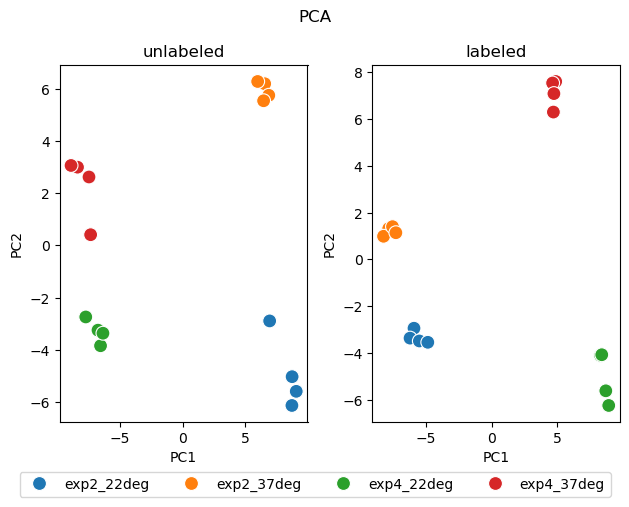

In [42]:
# PCA scores in DataFrame
pca_df = pd.DataFrame(scores, columns=['PC1', 'PC2'])
pca_l_df = pd.DataFrame(scores_l, columns=['PC1', 'PC2'])

# add groups
groups = ["exp2_22deg"]*4 + ["exp2_37deg"]*4 + ["exp4_22deg"]*4 + ["exp4_37deg"]*4
pca_df['group'] = groups
pca_l_df['group'] = groups

# Plot
fig, axs = plt.subplots(1, 2)
titles = ["unlabeled", "labeled"]

for i, d in enumerate([pca_df, pca_l_df]):
    sns.scatterplot(data=d, x="PC1", y="PC2", hue="group", s=100, ax=axs[i])
    axs[i].set_title(f"{titles[i]}")
    axs[i].legend().remove()

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("PCA")
plt.tight_layout()

# To Do
- summen von label+unlabeled zusammen. 
- analyse getrennt nach exp2, und 4. 


# Notes

# Questions
- ttest depending on skewness?
- Sind exp2 und exp4 exakt gleich durchgeführt?
